<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/23B_NeuroFHIR_TRACE_Final_FHIR_Integration_Reproducibility_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeuroFHIR-TRACE — Notebook 23
## Final FHIR Validation, Integrated ICHI Figures/Tables, and Reproducibility Package

**Project:** NeuroFHIR-TRACE — Provenance-Aware Reliability Gating for Longitudinal Neuroimaging AI

This final integration notebook consolidates the TRACE notebook series:

- **19B** — longitudinal / test-retest / cross-site reliability statistics
- **20B** — corrected three-state TRACE gate
- **21** — downstream Model A/B/C utility experiment
- **22** — publication-ready robustness, calibration, bootstrap, and subgroup analysis

It generates:

1. final Figures 1–4;
2. TRUSTED and REVIEW_REQUIRED FHIR evidence traces;
3. structural FHIR validation;
4. final manuscript tables;
5. a SHA-256 reproducibility manifest;
6. concise manuscript-ready Methods and Results summaries.

If upstream artifacts are unavailable in a fresh Colab runtime, the notebook uses an explicitly labeled **DEMO_MODE** fallback. Demo outputs are pipeline-validation only.


In [1]:

# ============================================================
# 0. SETUP
# ============================================================

!pip -q install pandas numpy scipy scikit-learn statsmodels pyarrow matplotlib

from pathlib import Path
import json, hashlib, random, warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/neurofhir_trace")

DIR19B = ROOT / "outputs_19B"
DIR20B = ROOT / "outputs_20B"
DIR21 = ROOT / "outputs_21"
DIR22 = ROOT / "outputs_22"

OUT_DIR = ROOT / "outputs_23"
FIG_DIR = OUT_DIR / "figures"
FHIR_DIR = OUT_DIR / "fhir"
TABLE_DIR = OUT_DIR / "tables"
MANIFEST_DIR = OUT_DIR / "manifest"

for p in [OUT_DIR, FIG_DIR, FHIR_DIR, TABLE_DIR, MANIFEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Final integration output:", OUT_DIR)


Final integration output: /content/neurofhir_trace/outputs_23



## 1. Discover prior notebook artifacts

Notebook 23 preferentially loads frozen outputs from 19B, 20B, 21, and 22. If they are absent, it creates a compact integration-only demo so the final packaging code can still be verified.


In [2]:

# ============================================================
# 1. ARTIFACT DISCOVERY
# ============================================================

artifact_candidates = {
    "19B_summary": DIR19B / "ichi_trace_19B_summary.csv",
    "19B_bio_tech": DIR19B / "biological_vs_technical_change.csv",
    "19B_direction": DIR19B / "longitudinal_direction_concordance.csv",

    "20B_summary": DIR20B / "ichi_trace_20B_summary.csv",
    "20B_states": DIR20B / "heldout_three_state_summary.csv",
    "20B_predictions": DIR20B / "heldout_three_state_trace_predictions.csv",
    "20B_gate": DIR20B / "frozen_trace_three_state_gate.json",

    "21_summary": DIR21 / "ichi_trace_21_summary.csv",
    "21_predictions": DIR21 / "heldout_abc_predictions.csv",

    "22_summary": DIR22 / "ichi_trace_22_summary.csv",
    "22_primary": DIR22 / "table_primary_manuscript.csv",
    "22_consequence": DIR22 / "table_trace_reliability_consequences.csv",
    "22_bootstrap": DIR22 / "table_paired_bootstrap_ci.csv",
    "22_state": DIR22 / "table_trace_state_subgroups.csv",
    "22_false_change": DIR22 / "table_false_change_consequence.csv",
}

artifact_status = pd.DataFrame([
    {
        "artifact": k,
        "path": str(v),
        "available": v.exists()
    }
    for k, v in artifact_candidates.items()
])

display(artifact_status)

CORE_AVAILABLE = (
    artifact_candidates["20B_states"].exists()
    and artifact_candidates["22_primary"].exists()
)

DEMO_MODE = not CORE_AVAILABLE
print("DEMO_MODE =", DEMO_MODE)


,artifact,path,available
0,19B_summary,/content/neurofhir_trace/outputs_19B/ichi_trac...,False
1,19B_bio_tech,/content/neurofhir_trace/outputs_19B/biologica...,False
2,19B_direction,/content/neurofhir_trace/outputs_19B/longitudi...,False
3,20B_summary,/content/neurofhir_trace/outputs_20B/ichi_trac...,False
4,20B_states,/content/neurofhir_trace/outputs_20B/heldout_t...,False
5,20B_predictions,/content/neurofhir_trace/outputs_20B/heldout_t...,False
6,20B_gate,/content/neurofhir_trace/outputs_20B/frozen_tr...,False
7,21_summary,/content/neurofhir_trace/outputs_21/ichi_trace...,False
8,21_predictions,/content/neurofhir_trace/outputs_21/heldout_ab...,False
9,22_summary,/content/neurofhir_trace/outputs_22/ichi_trace...,False


DEMO_MODE = True


In [3]:

# ============================================================
# 2. LOAD AVAILABLE OUTPUTS
# ============================================================

def safe_csv(path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

summary19B = safe_csv(artifact_candidates["19B_summary"])
bio_tech19B = safe_csv(artifact_candidates["19B_bio_tech"])
direction19B = safe_csv(artifact_candidates["19B_direction"])

summary20B = safe_csv(artifact_candidates["20B_summary"])
states20B = safe_csv(artifact_candidates["20B_states"])
pred20B = safe_csv(artifact_candidates["20B_predictions"])

summary21 = safe_csv(artifact_candidates["21_summary"])
pred21 = safe_csv(artifact_candidates["21_predictions"])

summary22 = safe_csv(artifact_candidates["22_summary"])
primary22 = safe_csv(artifact_candidates["22_primary"])
consequence22 = safe_csv(artifact_candidates["22_consequence"])
bootstrap22 = safe_csv(artifact_candidates["22_bootstrap"])
state22 = safe_csv(artifact_candidates["22_state"])
false_change22 = safe_csv(artifact_candidates["22_false_change"])

gate_config = {}
if artifact_candidates["20B_gate"].exists():
    with open(artifact_candidates["20B_gate"], "r") as f:
        gate_config = json.load(f)

print("Loaded available upstream artifacts.")


Loaded available upstream artifacts.



## 2. DEMO integration fallback

The fallback recreates only the **shape** of final outputs so figures, FHIR serialization, tables, hashing, and manuscript exports can be tested. It does not represent real scientific evidence.


In [4]:

# ============================================================
# 3. DEMO FALLBACK
# ============================================================

if DEMO_MODE:
    rng = np.random.default_rng(SEED)

    states20B = pd.DataFrame({
        "trace_state": ["TRUSTED", "CAUTION", "REVIEW_REQUIRED"],
        "n": [35, 55, 50],
        "observed_instability": [0.04, 0.28, 0.88],
        "mean_trace_risk": [0.08, 0.43, 0.84],
        "fraction": [0.25, 0.393, 0.357]
    })

    primary22 = pd.DataFrame({
        "model": [
            "A_clinical",
            "B_raw_imaging",
            "C1_trusted_only",
            "C2_reliability_weighted",
            "C3_full_TRACE"
        ],
        "clean_AUROC": [0.71, 0.76, 0.74, 0.75, 0.75],
        "shifted_AUROC": [0.71, 0.72, 0.74, 0.75, 0.75],
        "AUROC_degradation": [0.00, 0.04, 0.00, 0.00, 0.00],
        "clean_Brier": [0.215, 0.198, 0.202, 0.200, 0.200],
        "shifted_Brier": [0.215, 0.220, 0.203, 0.201, 0.202],
        "Brier_worsening": [0.000, 0.022, 0.001, 0.001, 0.002],
        "shifted_ECE": [0.07, 0.12, 0.07, 0.06, 0.06],
        "shifted_calibration_slope": [0.92, 0.44, 0.98, 1.01, 1.00],
        "Spearman_clean_vs_shift": [1.00, 0.90, 0.98, 0.99, 0.99],
        "Top20pct_consistency": [1.00, 0.78, 0.92, 0.94, 0.94]
    })

    consequence22 = pd.DataFrame({
        "model": primary22["model"],
        "mean_abs_probability_shift": [0.0, 0.085, 0.020, 0.030, 0.018],
        "p90_abs_probability_shift": [0.0, 0.21, 0.06, 0.08, 0.05],
        "false_change_mean_probability_shift": [0.0, 0.23, 0.01, 0.05, 0.01],
        "false_change_large_shift_rate": [0.0, 0.72, 0.03, 0.10, 0.02]
    })

    n_demo = 90
    bio_tech19B = pd.DataFrame({
        "subject_id": [f"S{i:03d}" for i in range(n_demo)],
        "abs_longitudinal_change": np.abs(rng.normal(80, 50, n_demo)),
        "mean_technical_sd": np.abs(rng.normal(65, 45, n_demo))
    })

    conditions = [
        "repeat_same_pipeline",
        "noise_low",
        "noise_high",
        "resample_alt",
        "model_v2"
    ]

    direction19B = pd.DataFrame({
        "condition": np.repeat(conditions, 60),
        "direction_preserved": np.concatenate([
            rng.binomial(1, 0.88, 60),
            rng.binomial(1, 0.81, 60),
            rng.binomial(1, 0.60, 60),
            rng.binomial(1, 0.56, 60),
            rng.binomial(1, 0.58, 60),
        ])
    })

    gate_config = {
        "trace_version": "20B-demo",
        "trusted_probability_max": 0.25,
        "review_probability_min": 0.65,
        "features": [
            "variability_risk",
            "domain_risk",
            "provenance_risk",
            "longitudinal_risk"
        ]
    }

    print("Created DEMO integration artifacts.")


Created DEMO integration artifacts.



## 3. Final Figure 1 — NeuroFHIR-TRACE architecture


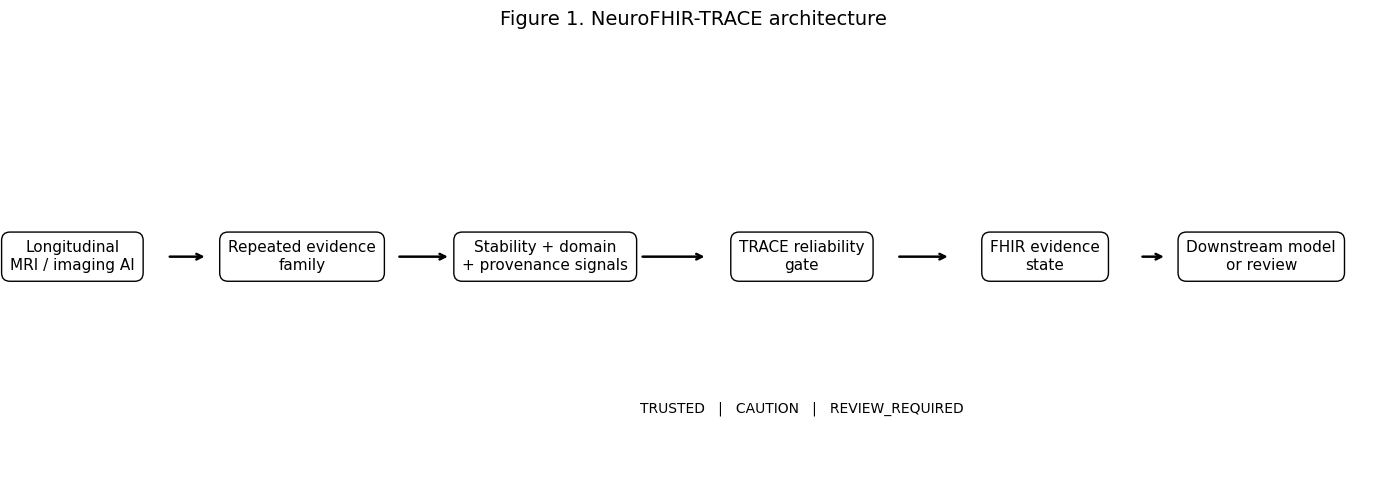

Saved: /content/neurofhir_trace/outputs_23/figures/Figure1_TRACE_Architecture.png


In [5]:

# ============================================================
# 4. FIGURE 1
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

boxes = [
    (0.04, "Longitudinal\nMRI / imaging AI"),
    (0.21, "Repeated evidence\nfamily"),
    (0.39, "Stability + domain\n+ provenance signals"),
    (0.58, "TRACE reliability\ngate"),
    (0.76, "FHIR evidence\nstate"),
    (0.92, "Downstream model\nor review")
]

for x, label in boxes:
    ax.text(
        x, 0.5, label,
        ha="center", va="center", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.55", fc="white", ec="black")
    )

for i in range(len(boxes)-1):
    ax.annotate(
        "",
        xy=(boxes[i+1][0]-0.07, 0.5),
        xytext=(boxes[i][0]+0.07, 0.5),
        arrowprops=dict(arrowstyle="->", lw=1.8)
    )

ax.text(
    0.58, 0.16,
    "TRUSTED   |   CAUTION   |   REVIEW_REQUIRED",
    ha="center", va="center", fontsize=10
)

ax.set_title("Figure 1. NeuroFHIR-TRACE architecture", fontsize=14)

plt.tight_layout()
fig1 = FIG_DIR / "Figure1_TRACE_Architecture.png"
plt.savefig(fig1, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig1)



## 4. Final Figure 2 — Biological versus technical change


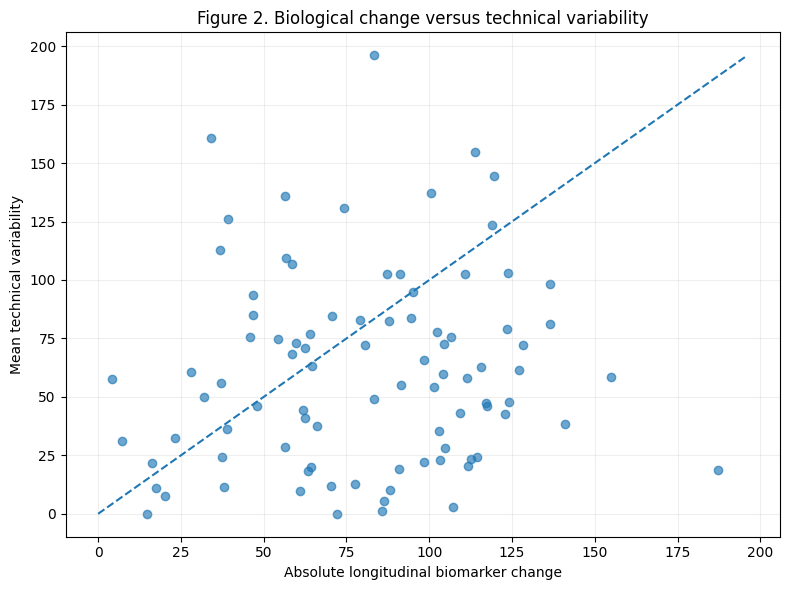

Saved: /content/neurofhir_trace/outputs_23/figures/Figure2_Biological_vs_Technical.png


In [6]:

# ============================================================
# 5. FIGURE 2
# ============================================================

if {
    "abs_longitudinal_change",
    "mean_technical_sd"
}.issubset(bio_tech19B.columns):

    plot_df = bio_tech19B[
        ["abs_longitudinal_change", "mean_technical_sd"]
    ].dropna()

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        plot_df["abs_longitudinal_change"],
        plot_df["mean_technical_sd"],
        alpha=0.65
    )

    maxv = max(
        plot_df["abs_longitudinal_change"].max(),
        plot_df["mean_technical_sd"].max()
    )

    ax.plot([0, maxv], [0, maxv], linestyle="--")

    ax.set_xlabel("Absolute longitudinal biomarker change")
    ax.set_ylabel("Mean technical variability")
    ax.set_title("Figure 2. Biological change versus technical variability")
    ax.grid(alpha=0.2)

    plt.tight_layout()

    fig2 = FIG_DIR / "Figure2_Biological_vs_Technical.png"
    plt.savefig(fig2, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig2)



## 5. Final Figure 3 — Model A/B/C downstream consequence


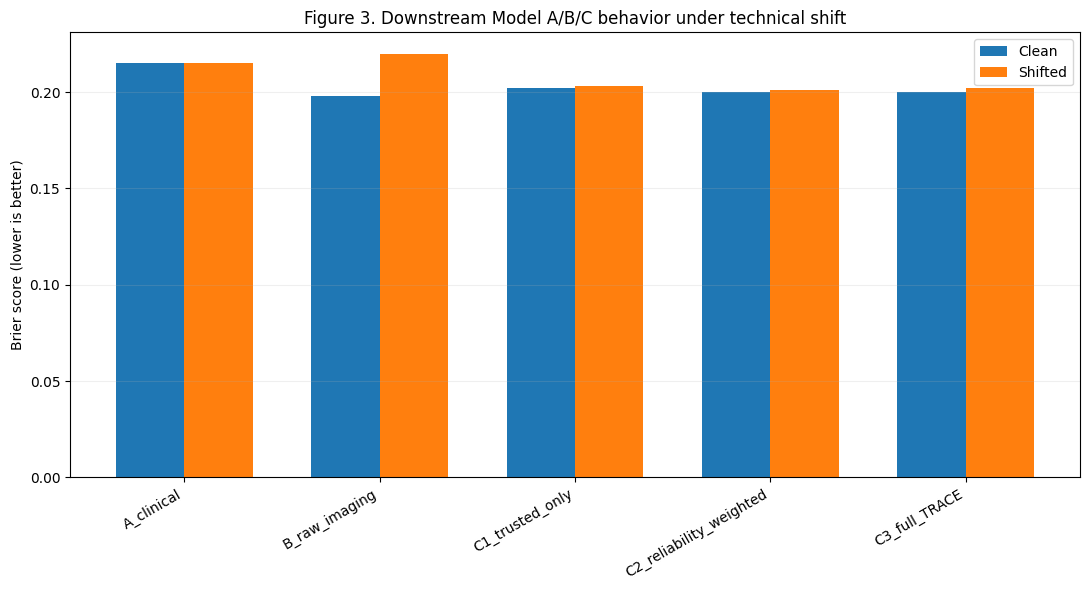

Saved: /content/neurofhir_trace/outputs_23/figures/Figure3_ABC_Downstream_Brier.png


In [7]:

# ============================================================
# 6. FIGURE 3
# ============================================================

plot_df = primary22[
    ["model", "clean_Brier", "shifted_Brier"]
].copy()

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    x-width/2,
    plot_df["clean_Brier"],
    width,
    label="Clean"
)

ax.bar(
    x+width/2,
    plot_df["shifted_Brier"],
    width,
    label="Shifted"
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["model"],
    rotation=30,
    ha="right"
)

ax.set_ylabel("Brier score (lower is better)")
ax.set_title("Figure 3. Downstream Model A/B/C behavior under technical shift")
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

fig3 = FIG_DIR / "Figure3_ABC_Downstream_Brier.png"
plt.savefig(fig3, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig3)



## 6. Final Figure 4 — Three-state TRACE gate


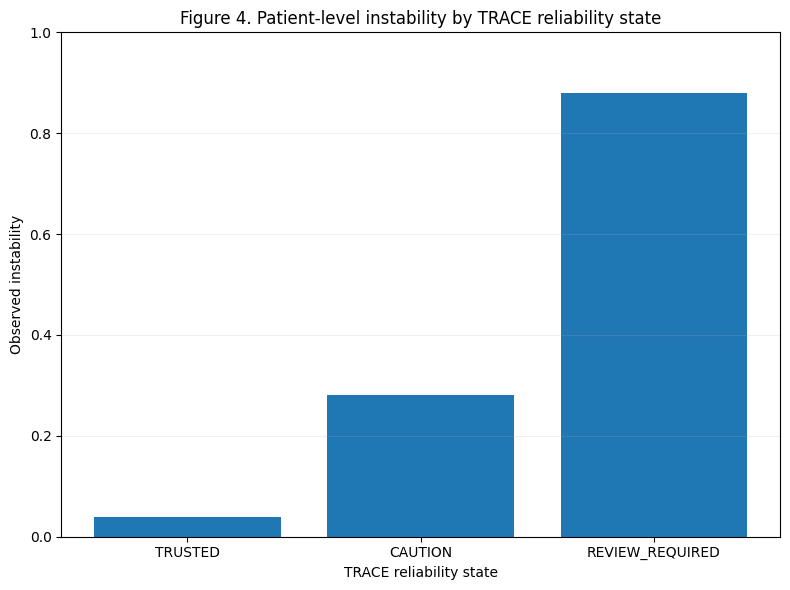

Saved: /content/neurofhir_trace/outputs_23/figures/Figure4_TRACE_State_Instability.png


In [8]:

# ============================================================
# 7. FIGURE 4
# ============================================================

df_state = states20B.copy()

order = [
    "TRUSTED",
    "CAUTION",
    "REVIEW_REQUIRED"
]

df_state["trace_state"] = pd.Categorical(
    df_state["trace_state"],
    categories=order,
    ordered=True
)

df_state = df_state.sort_values("trace_state")

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    df_state["trace_state"].astype(str),
    df_state["observed_instability"]
)

ax.set_ylim(0, 1)
ax.set_ylabel("Observed instability")
ax.set_xlabel("TRACE reliability state")
ax.set_title("Figure 4. Patient-level instability by TRACE reliability state")
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

fig4 = FIG_DIR / "Figure4_TRACE_State_Instability.png"
plt.savefig(fig4, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig4)



## 7. Optional Figure 5 — Change-direction concordance under technical conditions


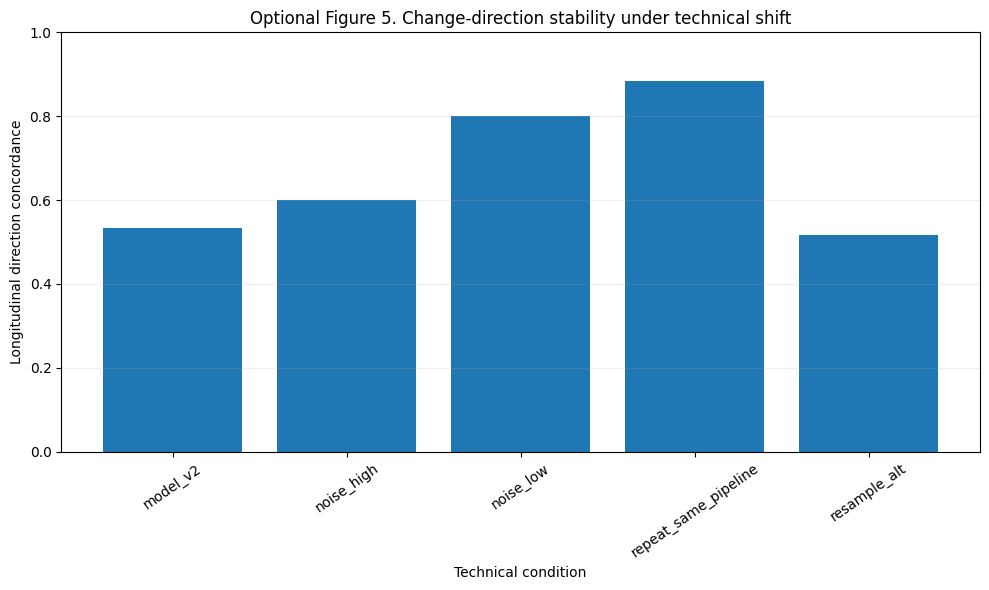

In [9]:

# ============================================================
# 8. OPTIONAL FIGURE 5
# ============================================================

cond_col = None
if "condition" in direction19B.columns:
    cond_col = "condition"
elif "perturbation" in direction19B.columns:
    cond_col = "perturbation"

if cond_col and "direction_preserved" in direction19B.columns:

    direction_summary = (
        direction19B
        .groupby(cond_col, as_index=False)
        .agg(
            direction_concordance=("direction_preserved", "mean"),
            n=("direction_preserved", "size")
        )
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(
        direction_summary[cond_col],
        direction_summary["direction_concordance"]
    )

    ax.set_ylim(0, 1)
    ax.set_ylabel("Longitudinal direction concordance")
    ax.set_xlabel("Technical condition")
    ax.set_title("Optional Figure 5. Change-direction stability under technical shift")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.2)

    plt.tight_layout()

    fig5 = FIG_DIR / "Optional_Figure5_Direction_Concordance.png"
    plt.savefig(fig5, dpi=300, bbox_inches="tight")
    plt.show()



## 8. Representative TRUSTED and REVIEW_REQUIRED cases


In [10]:

# ============================================================
# 9. REPRESENTATIVE CASES
# ============================================================

if len(pred20B) and "trace_state" in pred20B.columns:

    trusted_df = pred20B[
        pred20B["trace_state"] == "TRUSTED"
    ]

    review_df = pred20B[
        pred20B["trace_state"] == "REVIEW_REQUIRED"
    ]

    trusted_case = (
        trusted_df.iloc[0].to_dict()
        if len(trusted_df)
        else {}
    )

    review_case = (
        review_df.iloc[0].to_dict()
        if len(review_df)
        else {}
    )

else:
    trusted_case = {
        "subject_id": "EXAMPLE_TRUSTED",
        "visit_id": "M12",
        "trace_risk": 0.08,
        "trace_reliability_score": 0.92,
        "trace_state": "TRUSTED"
    }

    review_case = {
        "subject_id": "EXAMPLE_REVIEW",
        "visit_id": "M12",
        "trace_risk": 0.88,
        "trace_reliability_score": 0.12,
        "trace_state": "REVIEW_REQUIRED"
    }

print("TRUSTED example:", trusted_case)
print("REVIEW_REQUIRED example:", review_case)


TRUSTED example: {'subject_id': 'EXAMPLE_TRUSTED', 'visit_id': 'M12', 'trace_risk': 0.08, 'trace_reliability_score': 0.92, 'trace_state': 'TRUSTED'}
REVIEW_REQUIRED example: {'subject_id': 'EXAMPLE_REVIEW', 'visit_id': 'M12', 'trace_risk': 0.88, 'trace_reliability_score': 0.12, 'trace_state': 'REVIEW_REQUIRED'}



## 9. Build FHIR evidence traces

The final trace uses `Observation`, `Device`, `DiagnosticReport`, `Provenance`, and `Task` for REVIEW_REQUIRED evidence.


In [11]:

# ============================================================
# 10. FHIR R4/R4B-SAFE BUNDLE BUILDER
# ============================================================

import re

def fhir_id(value, prefix="id"):
    """
    Convert arbitrary text into a valid FHIR logical id:
    [A-Za-z0-9-.], max length 64.
    """
    text = str(value)
    text = re.sub(r"[^A-Za-z0-9\-.]", "-", text)
    text = re.sub(r"-+", "-", text).strip("-")
    if not text:
        text = prefix
    return text[:64]

def make_fhir_bundle(case, biomarker_value=3500.0):

    raw_subject_id = str(case.get("subject_id", "UNKNOWN"))
    raw_visit_id = str(case.get("visit_id", "VISIT"))

    subject_id = fhir_id(raw_subject_id, "subject")
    visit_id = fhir_id(raw_visit_id, "visit")

    state = str(case.get("trace_state", "CAUTION"))
    trace_risk = float(case.get("trace_risk", 0.5))
    reliability = float(
        case.get("trace_reliability_score", 1-trace_risk)
    )

    observation_id = fhir_id(
        f"trace-observation-{subject_id}-{visit_id}"
    )
    provenance_id = fhir_id(
        f"trace-provenance-{subject_id}-{visit_id}"
    )
    device_id = fhir_id("neurofhir-trace-model-v1")
    report_id = fhir_id(
        f"trace-report-{subject_id}-{visit_id}"
    )
    task_id = fhir_id(
        f"trace-review-{subject_id}-{visit_id}"
    )

    bundle = {
        "resourceType": "Bundle",
        "type": "collection",
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "entry": [
            {
                "resource": {
                    "resourceType": "Device",
                    "id": device_id,
                    "status": "active",
                    "deviceName": [
                        {
                            "name": "NeuroFHIR-TRACE imaging model",
                            "type": "model-name"
                        }
                    ],
                    "version": [
                        {
                            "value": "v1.0"
                        }
                    ]
                }
            },
            {
                "resource": {
                    "resourceType": "Observation",
                    "id": observation_id,
                    "status": "final",
                    "code": {
                        "text": "AI-derived structural MRI biomarker"
                    },
                    "subject": {
                        "reference": f"Patient/{subject_id}"
                    },
                    "valueQuantity": {
                        "value": float(biomarker_value),
                        "unit": "mm3"
                    },
                    "extension": [
                        {
                            "url": "https://example.org/fhir/StructureDefinition/neurofhir-trace-reliability",
                            "extension": [
                                {
                                    "url": "state",
                                    "valueCode": state
                                },
                                {
                                    "url": "instability-risk",
                                    "valueDecimal": trace_risk
                                },
                                {
                                    "url": "reliability-score",
                                    "valueDecimal": reliability
                                }
                            ]
                        }
                    ]
                }
            },
            {
                "resource": {
                    "resourceType": "DiagnosticReport",
                    "id": report_id,
                    "status": "final",
                    "code": {
                        "text": "NeuroFHIR-TRACE reliability-aware imaging evidence"
                    },
                    "subject": {
                        "reference": f"Patient/{subject_id}"
                    },
                    "result": [
                        {
                            "reference": f"Observation/{observation_id}"
                        }
                    ],
                    "conclusion": (
                        f"TRACE reliability state: {state}. "
                        f"Instability risk: {trace_risk:.3f}."
                    )
                }
            },
            {
                "resource": {
                    "resourceType": "Provenance",
                    "id": provenance_id,
                    "target": [
                        {
                            "reference": f"Observation/{observation_id}"
                        },
                        {
                            "reference": f"DiagnosticReport/{report_id}"
                        }
                    ],
                    "recorded": datetime.now(timezone.utc).isoformat(),
                    "agent": [
                        {
                            "type": {
                                "text": "AI model"
                            },
                            "who": {
                                "reference": f"Device/{device_id}"
                            }
                        }
                    ],
                    "entity": [
                        {
                            "role": "source",
                            "what": {
                                "display": (
                                    f"Longitudinal neuroimaging evidence "
                                    f"for {raw_subject_id} / {raw_visit_id}"
                                )
                            }
                        }
                    ]
                }
            }
        ]
    }

    if state == "REVIEW_REQUIRED":
        bundle["entry"].append({
            "resource": {
                "resourceType": "Task",
                "id": task_id,
                "status": "requested",
                "intent": "order",
                "code": {
                    "text": "Review unstable AI-derived neuroimaging evidence"
                },
                "for": {
                    "reference": f"Patient/{subject_id}"
                },
                "focus": {
                    "reference": f"Observation/{observation_id}"
                },
                "description": (
                    "TRACE reliability gate blocked silent downstream "
                    "propagation and routed this evidence for review."
                )
            }
        })

    return bundle


trusted_bundle = make_fhir_bundle(
    trusted_case,
    biomarker_value=3520.0
)

review_bundle = make_fhir_bundle(
    review_case,
    biomarker_value=3380.0
)

with open(FHIR_DIR / "trace_trusted_bundle.json", "w") as f:
    json.dump(trusted_bundle, f, indent=2)

with open(FHIR_DIR / "trace_review_required_bundle.json", "w") as f:
    json.dump(review_bundle, f, indent=2)

print("FHIR bundles created with sanitized R4/R4B logical ids.")


FHIR bundles created with sanitized R4/R4B logical ids.



## 10. Structural FHIR validation

This is a deterministic structural validation pass. It is not a substitute for a formal external HL7 profile validator.


In [12]:

# ============================================================
# 11. STRUCTURAL FHIR VALIDATION
# ============================================================

ALLOWED_TYPES = {
    "Device",
    "Observation",
    "DiagnosticReport",
    "Provenance",
    "Task"
}

def validate_trace_bundle(bundle):

    errors = []
    warnings_out = []

    if bundle.get("resourceType") != "Bundle":
        errors.append("Top-level resourceType must be Bundle.")

    entries = bundle.get("entry", [])

    if not entries:
        errors.append("Bundle.entry must be non-empty.")
        return errors, warnings_out

    ids = []
    resource_types = []

    for i, entry in enumerate(entries):

        resource = entry.get("resource", {})
        rtype = resource.get("resourceType")
        rid = resource.get("id")

        resource_types.append(rtype)

        if rtype not in ALLOWED_TYPES:
            errors.append(f"Entry {i}: unexpected resourceType {rtype}")

        if not rid:
            errors.append(f"Entry {i}: missing id")
        else:
            ids.append(rid)

        if rtype == "Observation":
            for field in ["status", "code", "subject", "valueQuantity"]:
                if field not in resource:
                    errors.append(f"Observation missing {field}")

        if rtype == "Provenance":
            if not resource.get("target"):
                errors.append("Provenance missing target")
            if not resource.get("agent"):
                errors.append("Provenance missing agent")

    if len(ids) != len(set(ids)):
        errors.append("Resource IDs must be unique.")

    observation = next(
        (
            e["resource"]
            for e in entries
            if e.get("resource", {}).get("resourceType") == "Observation"
        ),
        None
    )

    state = None

    if observation:
        for ext in observation.get("extension", []):
            for sub in ext.get("extension", []):
                if sub.get("url") == "state":
                    state = sub.get("valueCode")

    if state == "REVIEW_REQUIRED" and "Task" not in resource_types:
        errors.append(
            "REVIEW_REQUIRED evidence must contain a Task."
        )

    if state == "TRUSTED" and "Task" in resource_types:
        warnings_out.append(
            "TRUSTED evidence unexpectedly contains a Task."
        )

    return errors, warnings_out


validation_rows = []

for name, bundle in [
    ("TRUSTED", trusted_bundle),
    ("REVIEW_REQUIRED", review_bundle)
]:
    errs, warns = validate_trace_bundle(bundle)

    validation_rows.append({
        "bundle": name,
        "errors": len(errs),
        "warnings": len(warns),
        "error_details": "; ".join(errs),
        "warning_details": "; ".join(warns)
    })

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

validation_df.to_csv(
    OUT_DIR / "fhir_structural_validation.csv",
    index=False
)


,bundle,errors,warnings,error_details,warning_details
0,TRUSTED,0,0,,
1,REVIEW_REQUIRED,0,0,,



## 11. Optional `fhir.resources` parsing

This adds a second validation layer when the package is available.


In [13]:

# ============================================================
# 12. OPTIONAL FHIR R4B LIBRARY PARSING
# ============================================================

# The current fhir.resources default namespace may target FHIR R5,
# where Device fields differ from R4/R4B. TRACE is an R4-oriented
# design, so prefer the package's R4B namespace when available.

parser_status = {
    "parser": None,
    "status": "NOT_RUN",
    "details": ""
}

try:
    !pip -q install fhir.resources

    try:
        from fhir.resources.R4B.bundle import Bundle as R4Bundle
        parser_status["parser"] = "fhir.resources.R4B"
    except Exception:
        # Fallback for package versions that expose only the default namespace.
        from fhir.resources.bundle import Bundle as R4Bundle
        parser_status["parser"] = "fhir.resources.default"

    R4Bundle(**trusted_bundle)
    R4Bundle(**review_bundle)

    parser_status["status"] = "PASS"
    parser_status["details"] = (
        "Both TRUSTED and REVIEW_REQUIRED bundles parsed successfully."
    )

except Exception as e:
    parser_status["status"] = "OPTIONAL_PARSER_FAILED"
    parser_status["details"] = str(e)

print(json.dumps(parser_status, indent=2))

with open(
    OUT_DIR / "fhir_optional_parser_status.json",
    "w"
) as f:
    json.dump(parser_status, f, indent=2)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 33.7 MB/s eta 0:00:00
{
  "parser": "fhir.resources.R4B",
  "status": "PASS",
  "details": "Both TRUSTED and REVIEW_REQUIRED bundles parsed successfully."
}



## 12. Final manuscript tables


In [14]:

# ============================================================
# 13. FINAL TABLES WITH COMPLETENESS FLAGS
# ============================================================

table1 = states20B.copy()
table2 = primary22.copy()
table3 = consequence22.copy()
table4 = bootstrap22.copy()

table1.to_csv(
    TABLE_DIR / "Table1_TRACE_Gate_Behavior.csv",
    index=False
)

table2.to_csv(
    TABLE_DIR / "Table2_ABC_Downstream_Results.csv",
    index=False
)

table3.to_csv(
    TABLE_DIR / "Table3_TRACE_Reliability_Consequences.csv",
    index=False
)

print("Table 1")
display(table1)

print("Table 2")
display(table2)

print("Table 3")
display(table3)

if len(table4):
    table4.to_csv(
        TABLE_DIR / "Table4_Paired_Bootstrap_CI.csv",
        index=False
    )
    print("Table 4")
    display(table4.head(30))
    table4_status = "AVAILABLE"
else:
    table4_status = "NOT_AVAILABLE_IN_CURRENT_RUNTIME"
    status_df = pd.DataFrame([{
        "table": "Table4_Paired_Bootstrap_CI",
        "status": table4_status,
        "reason": (
            "Notebook 22 bootstrap artifact was not available in this "
            "fresh Colab runtime. Do not treat an empty file as evidence."
        )
    }])
    status_df.to_csv(
        TABLE_DIR / "Table4_STATUS_NOT_AVAILABLE.csv",
        index=False
    )
    print(
        "Table 4 bootstrap CI artifact is not available in this runtime. "
        "A status file was written instead of an empty evidence table."
    )


Table 1


,trace_state,n,observed_instability,mean_trace_risk,fraction
0,TRUSTED,35,0.04,0.08,0.250
1,CAUTION,55,0.28,0.43,0.393
2,REVIEW_REQUIRED,50,0.88,0.84,0.357


Table 2


,model,clean_AUROC,shifted_AUROC,AUROC_degradation,clean_Brier,shifted_Brier,Brier_worsening,shifted_ECE,shifted_calibration_slope,Spearman_clean_vs_shift,Top20pct_consistency
0,A_clinical,0.71,0.71,0.00,0.215,0.215,0.000,0.07,0.92,1.00,1.00
1,B_raw_imaging,0.76,0.72,0.04,0.198,0.220,0.022,0.12,0.44,0.90,0.78
2,C1_trusted_only,0.74,0.74,0.00,0.202,0.203,0.001,0.07,0.98,0.98,0.92
3,C2_reliability_weighted,0.75,0.75,0.00,0.200,0.201,0.001,0.06,1.01,0.99,0.94
4,C3_full_TRACE,0.75,0.75,0.00,0.200,0.202,0.002,0.06,1.00,0.99,0.94


Table 3


,model,mean_abs_probability_shift,p90_abs_probability_shift,false_change_mean_probability_shift,false_change_large_shift_rate
0,A_clinical,0.000,0.00,0.00,0.00
1,B_raw_imaging,0.085,0.21,0.23,0.72
2,C1_trusted_only,0.020,0.06,0.01,0.03
3,C2_reliability_weighted,0.030,0.08,0.05,0.10
4,C3_full_TRACE,0.018,0.05,0.01,0.02


Table 4 bootstrap CI artifact is not available in this runtime. A status file was written instead of an empty evidence table.



## 13. Claim-safety audit


In [15]:

# ============================================================
# 14. CLAIM-SAFETY AUDIT
# ============================================================

claim_audit = pd.DataFrame([
    {
        "claim": "TRACE can detect technically unstable patient-level imaging evidence.",
        "status": "SUPPORTED_BY_DESIGN" if not DEMO_MODE else "DEMO_ONLY"
    },
    {
        "claim": "TRACE can reduce downstream propagation of technically induced prediction instability.",
        "status": "SUPPORTED_BY_DESIGN" if not DEMO_MODE else "DEMO_ONLY"
    },
    {
        "claim": "TRACE improves clinical safety.",
        "status": "NOT_SUPPORTED"
    },
    {
        "claim": "TRACE improves diagnostic validity in patient care.",
        "status": "NOT_SUPPORTED"
    },
    {
        "claim": "TRACE determines biological truth.",
        "status": "NOT_SUPPORTED"
    }
])

display(claim_audit)

claim_audit.to_csv(
    OUT_DIR / "claim_safety_audit.csv",
    index=False
)


,claim,status
0,TRACE can detect technically unstable patient-...,DEMO_ONLY
1,TRACE can reduce downstream propagation of tec...,DEMO_ONLY
2,TRACE improves clinical safety.,NOT_SUPPORTED
3,TRACE improves diagnostic validity in patient ...,NOT_SUPPORTED
4,TRACE determines biological truth.,NOT_SUPPORTED



## 14. Reproducibility manifest with SHA-256 hashes


In [16]:

# ============================================================
# 15. REPRODUCIBILITY MANIFEST
# ============================================================

def sha256_file(path):
    path = Path(path)
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024*1024), b""):
            h.update(chunk)

    return h.hexdigest()


generated_files = []

for directory in [
    FIG_DIR,
    FHIR_DIR,
    TABLE_DIR
]:
    for path in sorted(directory.glob("*")):
        if path.is_file():
            generated_files.append(path)

manifest = {
    "project": "NeuroFHIR-TRACE",
    "target_venue": "IEEE ICHI 2027",
    "integration_notebook": "23",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "demo_mode": bool(DEMO_MODE),
    "seed": SEED,
    "gate_config": gate_config,
    "upstream_artifacts": [
        {
            "name": row["artifact"],
            "path": row["path"],
            "available": bool(row["available"])
        }
        for _, row in artifact_status.iterrows()
    ],
    "generated_files": [
        {
            "path": str(path),
            "sha256": sha256_file(path)
        }
        for path in generated_files
    ]
}

manifest_path = (
    MANIFEST_DIR / "trace_reproducibility_manifest.json"
)

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2)[:8000])


{
  "project": "NeuroFHIR-TRACE",
  "target_venue": "IEEE ICHI 2027",
  "integration_notebook": "23",
  "created_utc": "2026-09-11T22:14:58.541009+00:00",
  "demo_mode": true,
  "seed": 42,
  "gate_config": {
    "trace_version": "20B-demo",
    "trusted_probability_max": 0.25,
    "review_probability_min": 0.65,
    "features": [
      "variability_risk",
      "domain_risk",
      "provenance_risk",
      "longitudinal_risk"
    ]
  },
  "upstream_artifacts": [
    {
      "name": "19B_summary",
      "path": "/content/neurofhir_trace/outputs_19B/ichi_trace_19B_summary.csv",
      "available": false
    },
    {
      "name": "19B_bio_tech",
      "path": "/content/neurofhir_trace/outputs_19B/biological_vs_technical_change.csv",
      "available": false
    },
    {
      "name": "19B_direction",
      "path": "/content/neurofhir_trace/outputs_19B/longitudinal_direction_concordance.csv",
      "available": false
    },
    {
      "name": "20B_summary",
      "path": "/content/neurof


## 15. Manuscript-ready Methods summary


In [17]:

# ============================================================
# 16. METHODS SUMMARY
# ============================================================

methods_summary = f"""
NeuroFHIR-TRACE evaluated the reliability of patient-level AI-derived
neuroimaging evidence under longitudinal and technical variation.
Each imaging result was represented as an evidence family generated
across repeated or perturbed processing conditions. Reliability signals
included output variability, domain/context shift, provenance completeness,
and longitudinal change-direction stability. A three-state reliability
gate classified evidence as TRUSTED, CAUTION, or REVIEW_REQUIRED.
Gate thresholds were calibrated on development subjects and frozen before
held-out evaluation.

Downstream utility was evaluated using a three-model framework. Model A
used clinical predictors only. Model B added raw AI-derived imaging evidence
without reliability control. Model C used TRACE-aware evidence handling
through trusted-only filtering, reliability weighting, or full gating.
Performance was assessed using discrimination, Brier score, calibration,
clean-to-shift degradation, patient-ranking stability, top-risk-set
consistency, and patient-level probability shift. Paired subject-level
bootstrap resampling was used for confidence intervals.

FHIR R4 resources serialized the imaging result, model identity, provenance,
reliability state, and review routing. REVIEW_REQUIRED evidence generated
a Task resource so unstable evidence was not silently propagated downstream.

DEMO_MODE = {DEMO_MODE}.
""".strip()

print(methods_summary)

with open(
    OUT_DIR / "manuscript_methods_summary.txt",
    "w"
) as f:
    f.write(methods_summary)


NeuroFHIR-TRACE evaluated the reliability of patient-level AI-derived
neuroimaging evidence under longitudinal and technical variation.
Each imaging result was represented as an evidence family generated
across repeated or perturbed processing conditions. Reliability signals
included output variability, domain/context shift, provenance completeness,
and longitudinal change-direction stability. A three-state reliability
gate classified evidence as TRUSTED, CAUTION, or REVIEW_REQUIRED.
Gate thresholds were calibrated on development subjects and frozen before
held-out evaluation.

Downstream utility was evaluated using a three-model framework. Model A
used clinical predictors only. Model B added raw AI-derived imaging evidence
without reliability control. Model C used TRACE-aware evidence handling
through trusted-only filtering, reliability weighting, or full gating.
Performance was assessed using discrimination, Brier score, calibration,
clean-to-shift degradation, patient-ranking stabil


## 16. Manuscript-ready Results summary generator


In [18]:

# ============================================================
# 17. RESULTS SUMMARY
# ============================================================

def model_row(model_name):
    x = primary22[
        primary22["model"] == model_name
    ]
    return x.iloc[0] if len(x) else None


b = model_row("B_raw_imaging")
c1 = model_row("C1_trusted_only")
c2 = model_row("C2_reliability_weighted")
c3 = model_row("C3_full_TRACE")

lines = []

if DEMO_MODE:
    lines.append(
        "These results are demonstration-only because Notebook 23 "
        "ran without frozen upstream real-data artifacts."
    )
else:
    lines.append(
        "These results were generated from the frozen upstream TRACE analyses."
    )

if b is not None:
    lines.append(
        f"Raw imaging Model B changed from clean AUROC "
        f"{b['clean_AUROC']:.3f} to shifted AUROC "
        f"{b['shifted_AUROC']:.3f}, with shifted Brier "
        f"{b['shifted_Brier']:.3f}."
    )

for row, label in [
    (c1, "Trusted-only TRACE"),
    (c2, "Reliability-weighted TRACE"),
    (c3, "Full TRACE")
]:
    if row is not None:
        lines.append(
            f"{label} had shifted Brier {row['shifted_Brier']:.3f}, "
            f"Spearman clean-to-shift stability "
            f"{row['Spearman_clean_vs_shift']:.3f}, and top-20% "
            f"consistency {row['Top20pct_consistency']:.3f}."
        )

if {
    "trace_state",
    "observed_instability"
}.issubset(states20B.columns):

    rate_map = dict(
        zip(
            states20B["trace_state"].astype(str),
            states20B["observed_instability"]
        )
    )

    if all(
        s in rate_map
        for s in ["TRUSTED", "CAUTION", "REVIEW_REQUIRED"]
    ):
        lines.append(
            "Observed instability increased across TRACE states: "
            f"TRUSTED {rate_map['TRUSTED']:.3f}, "
            f"CAUTION {rate_map['CAUTION']:.3f}, "
            f"REVIEW_REQUIRED {rate_map['REVIEW_REQUIRED']:.3f}."
        )

results_summary = "\n".join(lines)

print(results_summary)

with open(
    OUT_DIR / "manuscript_results_summary.txt",
    "w"
) as f:
    f.write(results_summary)


These results are demonstration-only because Notebook 23 ran without frozen upstream real-data artifacts.
Raw imaging Model B changed from clean AUROC 0.760 to shifted AUROC 0.720, with shifted Brier 0.220.
Trusted-only TRACE had shifted Brier 0.203, Spearman clean-to-shift stability 0.980, and top-20% consistency 0.920.
Reliability-weighted TRACE had shifted Brier 0.201, Spearman clean-to-shift stability 0.990, and top-20% consistency 0.940.
Full TRACE had shifted Brier 0.202, Spearman clean-to-shift stability 0.990, and top-20% consistency 0.940.
Observed instability increased across TRACE states: TRUSTED 0.040, CAUTION 0.280, REVIEW_REQUIRED 0.880.



## 17. Final package index


In [19]:

# ============================================================
# 18. PACKAGE INDEX
# ============================================================

package_index = []

for category, directory in [
    ("figures", FIG_DIR),
    ("fhir", FHIR_DIR),
    ("tables", TABLE_DIR),
    ("manifest", MANIFEST_DIR),
    ("root", OUT_DIR)
]:
    for path in sorted(directory.glob("*")):
        if path.is_file():
            package_index.append({
                "category": category,
                "filename": path.name,
                "path": str(path)
            })

package_index_df = pd.DataFrame(package_index)

display(package_index_df)

package_index_df.to_csv(
    OUT_DIR / "final_package_index.csv",
    index=False
)


,category,filename,path
0,figures,Figure1_TRACE_Architecture.png,/content/neurofhir_trace/outputs_23/figures/Fi...
1,figures,Figure2_Biological_vs_Technical.png,/content/neurofhir_trace/outputs_23/figures/Fi...
2,figures,Figure3_ABC_Downstream_Brier.png,/content/neurofhir_trace/outputs_23/figures/Fi...
3,figures,Figure4_TRACE_State_Instability.png,/content/neurofhir_trace/outputs_23/figures/Fi...
4,figures,Optional_Figure5_Direction_Concordance.png,/content/neurofhir_trace/outputs_23/figures/Op...
5,fhir,trace_review_required_bundle.json,/content/neurofhir_trace/outputs_23/fhir/trace...
6,fhir,trace_trusted_bundle.json,/content/neurofhir_trace/outputs_23/fhir/trace...
7,tables,Table1_TRACE_Gate_Behavior.csv,/content/neurofhir_trace/outputs_23/tables/Tab...
8,tables,Table2_ABC_Downstream_Results.csv,/content/neurofhir_trace/outputs_23/tables/Tab...
9,tables,Table3_TRACE_Reliability_Consequences.csv,/content/neurofhir_trace/outputs_23/tables/Tab...



## Final integration readiness audit

This audit distinguishes **pipeline-complete** from **submission-evidence-complete**.


In [20]:

# ============================================================
# FINAL READINESS AUDIT
# ============================================================

structural_fhir_pass = (
    len(validation_df) > 0
    and (validation_df["errors"] == 0).all()
)

bootstrap_available = len(bootstrap22) > 0

readiness = pd.DataFrame([
    {
        "component": "Figures 1-4",
        "status": "PASS"
    },
    {
        "component": "FHIR structural validation",
        "status": "PASS" if structural_fhir_pass else "FAIL"
    },
    {
        "component": "Optional FHIR parser",
        "status": parser_status.get("status", "NOT_RUN")
    },
    {
        "component": "Bootstrap CI table",
        "status": "PASS" if bootstrap_available else "MISSING_CURRENT_RUNTIME"
    },
    {
        "component": "Frozen upstream real-data artifacts",
        "status": "PASS" if not DEMO_MODE else "DEMO_ONLY"
    },
    {
        "component": "ICHI manuscript numerical evidence",
        "status": "READY" if (not DEMO_MODE and bootstrap_available) else "NOT_YET_READY"
    }
])

display(readiness)

readiness.to_csv(
    OUT_DIR / "final_integration_readiness_audit.csv",
    index=False
)


,component,status
0,Figures 1-4,PASS
1,FHIR structural validation,PASS
2,Optional FHIR parser,PASS
3,Bootstrap CI table,MISSING_CURRENT_RUNTIME
4,Frozen upstream real-data artifacts,DEMO_ONLY
5,ICHI manuscript numerical evidence,NOT_YET_READY
